## 1. Abstract / Annotation

This project analyses coffee shop sales data collected from a vending machine over the period from March 2024 to March 2025. The dataset contains transactional records including the type of beverage, payment method, price, and timestamp of each purchase. The goal of the analysis is to identify sales patterns, popular products, peak hours, and differences in spending behaviour between cash and card customers.

The dataset is composed of two separate CSV files that are merged into a single dataframe for analysis. All prices have been converted from Ukrainian hryvnias (UAH) to Russian rubles (RUB) at the rate of 1 UAH = 1.60 RUB (CBR rate as of June 13, 2026).

## 2. Dataset Description

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 12

In [4]:
# Load both files
df1 = pd.read_csv('index_1.csv')
df2 = pd.read_csv('index_2.csv')

# deleting card cpllum in df1
del df1['card']


print(f'index_1.csv: {df1.shape[0]} rows, {df1.shape[1]} columns')
print(f'index_2.csv: {df2.shape[0]} rows, {df2.shape[1]} columns')

index_1.csv: 3636 rows, 5 columns
index_2.csv: 262 rows, 5 columns


In [5]:
# Convert prices from UAH to RUB
RATE = 1.60
df1['money'] = (df1['money'] * RATE).round(2)
df2['money'] = (df2['money'] * RATE).round(2)

# df2 has no 'card' column — add it as NaN so both files match
df2['card'] = np.nan

# Merge into one dataframe
df = pd.concat([df1, df2], ignore_index=True)

print(f'Combined dataset: {df.shape[0]} rows, {df.shape[1]} columns')
df.head(10)

Combined dataset: 3898 rows, 6 columns


,date,datetime,cash_type,money,coffee_name,card
0,2024-03-01,2024-03-01 10:15:50.520,card,61.92,Latte,NaN
1,2024-03-01,2024-03-01 12:19:22.539,card,61.92,Hot Chocolate,NaN
2,2024-03-01,2024-03-01 12:20:18.089,card,61.92,Hot Chocolate,NaN
3,2024-03-01,2024-03-01 13:46:33.006,card,46.24,Americano,NaN
4,2024-03-01,2024-03-01 13:48:14.626,card,61.92,Latte,NaN
5,2024-03-01,2024-03-01 15:39:47.726,card,54.08,Americano with Milk,NaN
6,2024-03-01,2024-03-01 16:19:02.756,card,61.92,Hot Chocolate,NaN
7,2024-03-01,2024-03-01 18:39:03.580,card,54.08,Americano with Milk,NaN
8,2024-03-01,2024-03-01 19:22:01.762,card,61.92,Cocoa,NaN
9,2024-03-01,2024-03-01 19:23:15.887,card,54.08,Americano with Milk,NaN


In [6]:
# Fix data types — dates are stored as strings, convert them
# format='mixed' is needed because df1 has milliseconds, df2 does not
df['date']     = pd.to_datetime(df['date'], format='mixed')
df['datetime'] = pd.to_datetime(df['datetime'], format='mixed')

print('Column types after conversion:')
print(df.dtypes)

Column types after conversion:
date           datetime64[us]
datetime       datetime64[us]
cash_type                 str
money                 float64
coffee_name               str
card                  float64
dtype: object


In [7]:
# Missing values
print('Missing values per column:')
print(df.isna().sum())
print()
print('Note: NaN in "card" column is expected — cash transactions have no card number.')

Missing values per column:
date              0
datetime          0
cash_type         0
money             0
coffee_name       0
card           3898
dtype: int64

Note: NaN in "card" column is expected — cash transactions have no card number.


In [8]:
# Overview
print(f'Date range: from {df["date"].min().date()} to {df["date"].max().date()}')
print(f'Payment types: {df["cash_type"].unique().tolist()}')
print(f'Unique beverages: {df["coffee_name"].nunique()}')
print(f'Beverages: {sorted(df["coffee_name"].unique())}')

Date range: from 2024-03-01 to 2025-03-23
Payment types: ['card', 'cash']
Unique beverages: 34
Beverages: ['Americano', 'Americano with Milk', 'Americano with milk', 'Cappuccino', 'Caramel', 'Caramel coffee', 'Caramel with Irish whiskey', 'Caramel with chocolate', 'Caramel with milk', 'Chocolate', 'Chocolate with coffee', 'Chocolate with milk', 'Cocoa', 'Coffee with Irish whiskey', 'Coffee with chocolate', 'Cortado', 'Double Irish whiskey', 'Double chocolate', 'Double espresso', 'Double espresso with milk', 'Double ristretto', 'Double vanilla', 'Espresso', 'Hot Chocolate', 'Hot milkshake', 'Irish whiskey', 'Irish whiskey with milk', 'Irish with chocolate', 'Latte', 'Mochaccino', 'Super chocolate', 'Tea', 'Vanilla coffee', 'Vanilla with Irish whiskey']


## 3. Descriptive Statistics

We analyse four numeric fields: **money** (price in RUB), **hour** (hour of purchase), **day_of_week** (0 = Monday … 6 = Sunday), and **daily_revenue** (total revenue per day). For each field we compute mean, median, standard deviation, min and max.

In [9]:
# Derive numeric fields we will use throughout the project
df['hour'] = df['datetime'].dt.hour
df['day_of_week'] = df['datetime'].dt.dayofweek   # 0 = Monday, 6 = Sunday
df['day_name']  = df['datetime'].dt.day_name()  # Monday, Tuesday, ...
df['daily_revenue'] = df.groupby('date')['money'].transform('sum')

# Stats for numeric fields
numeric_cols = ['money', 'hour', 'daily_revenue']
stats = df[numeric_cols].agg(['mean', 'median', 'std', 'min', 'max']).round(2)
stats.index.name = 'stat'

# Day of week — show as names, not numbers
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_counts = df['day_name'].value_counts().reindex(day_order)
print('Purchases by day of week:')
print(day_counts.to_string())
print()
stats

Purchases by day of week:
day_name
Monday       591
Tuesday      604
Wednesday    553
Thursday     540
Friday       586
Saturday     531
Sunday       493



,money,hour,daily_revenue
stat,,,
mean,50.21,14.20,688.04
median,52.51,14.00,608.97
std,8.10,4.22,332.41
min,24.00,6.00,36.83
max,64.00,23.00,1566.62


In [10]:
# Per-beverage price statistics
price_stats = (
    df.groupby('coffee_name')['money']
    .agg(mean='mean', median='median', std='std', count='count')
    .round(2)
    .sort_values('mean', ascending=False)
)
print('Price statistics by beverage (RUB):')
price_stats

Price statistics by beverage (RUB):


,mean,median,std,count
coffee_name,,,,
Hot Chocolate,57.72,57.22,2.44,282
Cappuccino,57.30,57.22,3.43,517
Cocoa,57.14,57.22,2.09,243
Latte,56.89,57.22,3.14,806
Double espresso with milk,51.20,51.20,0.00,2
Americano with Milk,49.07,49.38,3.11,824
Hot milkshake,48.00,48.00,NaN,1
Mochaccino,48.00,48.00,0.00,5
Chocolate with coffee,48.00,48.00,0.00,5


In [11]:
# Payment method breakdown
pay_stats = (df.groupby('cash_type')['money'].agg(count='count', mean='mean', median='median', std='std')
.round(2)
)
print('Statistics by payment method (RUB):')
pay_stats

Statistics by payment method (RUB):


,count,mean,median,std
cash_type,,,,
card,3729,50.25,52.51,7.93
cash,169,49.30,48.00,11.25


**Key observations:**
- The average purchase price is **~50 RUB**, with a median of **~52 RUB** — the distribution is slightly left-skewed.
- Purchases happen between **6:00 and 23:00**, with a mean hour of ~14 (early afternoon).
- Hot Chocolate, Cappuccino and Cocoa are the most expensive beverages; Tea and Espresso are the cheapest.
- Card and cash customers show similar average spend, but we will test this formally in the Hypothesis section

## 4. Data Cleanup

We check for three types of issues: duplicate rows, missing values, and inconsistent category names. Below we document each problem found and fix it.

In [12]:
# --- Issue 1: Duplicate rows ---
print(f'Duplicate rows before cleanup: {df.duplicated().sum()}')
print(df[df.duplicated(keep=False)][['date', 'datetime', 'cash_type', 'money', 'coffee_name']])

df = df.drop_duplicates().reset_index(drop=True)
print(f'\nDuplicate rows after cleanup: {df.duplicated().sum()}')
print(f'Rows remaining: {len(df)}')

Duplicate rows before cleanup: 2
           date            datetime cash_type  money          coffee_name
3746 2025-02-26 2025-02-26 09:41:12      cash   40.0  Americano with milk
3747 2025-02-26 2025-02-26 09:41:12      cash   40.0  Americano with milk
3891 2025-03-23 2025-03-23 10:25:48      cash   40.0  Americano with milk
3892 2025-03-23 2025-03-23 10:25:48      cash   40.0  Americano with milk

Duplicate rows after cleanup: 0
Rows remaining: 3896


In [13]:
# --- Issue 2: NaN in 'card' column ---
# NaN is expected for cash payments — those rows are fine
# But some card transactions also have NaN card number (data from index_2 had no card column)
cash_nan   = df[(df['cash_type'] == 'cash')  & (df['card'].isna())].shape[0]
card_nan   = df[(df['cash_type'] == 'card')  & (df['card'].isna())].shape[0]
print(f'Cash rows with NaN card (expected):    {cash_nan}')
print(f'Card rows with NaN card (missing data): {card_nan}')
print()
# We keep these rows — the card number is not used in our analysis.
# We just fill NaN with a placeholder so the column is consistent.
df['card'] = df['card'].fillna('unknown')
print(f'NaN in card column after fix: {df["card"].isna().sum()}')

Cash rows with NaN card (expected):    167
Card rows with NaN card (missing data): 3729

NaN in card column after fix: 0


In [14]:
# --- Issue 3: Inconsistent capitalisation in coffee_name ---
# 'Americano with Milk' and 'Americano with milk' are the same drink
print('Before fix:')
print(df['coffee_name'].value_counts()[['Americano with Milk', 'Americano with milk']])

df['coffee_name'] = df['coffee_name'].str.strip()
df['coffee_name'] = df['coffee_name'].replace({'Americano with milk': 'Americano with Milk'})

print('\nAfter fix:')
print(df['coffee_name'].value_counts()[['Americano with Milk']])
print(f'\nTotal unique beverages now: {df["coffee_name"].nunique()}')

Before fix:
coffee_name
Americano with Milk    824
Americano with milk     42
Name: count, dtype: int64

After fix:
coffee_name
Americano with Milk    866
Name: count, dtype: int64

Total unique beverages now: 33


In [15]:
# --- Final check ---
print('Dataset after cleanup:')
print(f'  Rows:       {len(df)}')
print(f'  Columns:    {len(df.columns)}')
print(f'  NaN values: {df.isna().sum().sum()}')
print(f'  Duplicates: {df.duplicated().sum()}')
print()
print('The data is now clean and ready for analysis.')
df.head(10)

Dataset after cleanup:
  Rows:       3896
  Columns:    10
  NaN values: 0
  Duplicates: 0

The data is now clean and ready for analysis.


,date,datetime,cash_type,money,coffee_name,card,hour,day_of_week,day_name,daily_revenue
0,2024-03-01,2024-03-01 10:15:50.520,card,61.92,Latte,unknown,10,4,Friday,634.08
1,2024-03-01,2024-03-01 12:19:22.539,card,61.92,Hot Chocolate,unknown,12,4,Friday,634.08
2,2024-03-01,2024-03-01 12:20:18.089,card,61.92,Hot Chocolate,unknown,12,4,Friday,634.08
3,2024-03-01,2024-03-01 13:46:33.006,card,46.24,Americano,unknown,13,4,Friday,634.08
4,2024-03-01,2024-03-01 13:48:14.626,card,61.92,Latte,unknown,13,4,Friday,634.08
5,2024-03-01,2024-03-01 15:39:47.726,card,54.08,Americano with Milk,unknown,15,4,Friday,634.08
6,2024-03-01,2024-03-01 16:19:02.756,card,61.92,Hot Chocolate,unknown,16,4,Friday,634.08
7,2024-03-01,2024-03-01 18:39:03.580,card,54.08,Americano with Milk,unknown,18,4,Friday,634.08
8,2024-03-01,2024-03-01 19:22:01.762,card,61.92,Cocoa,unknown,19,4,Friday,634.08
9,2024-03-01,2024-03-01 19:23:15.887,card,54.08,Americano with Milk,unknown,19,4,Friday,634.08


## 5. Plots

We use five plots of four different types to get a visual overview of the data: a histogram, a bar chart, a line chart, a horizontal bar chart, and a pie chart.

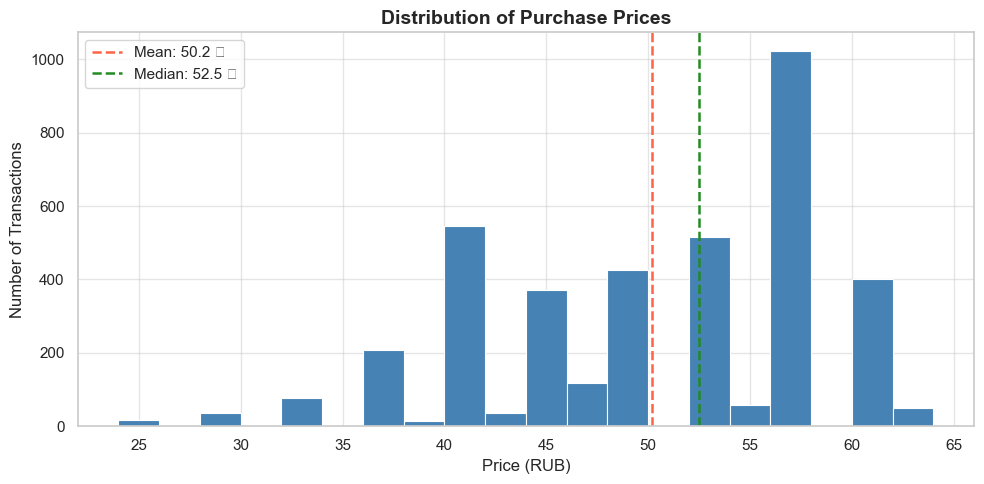

Most purchases cluster around 52 ₽, with a secondary peak near 45 ₽.


In [16]:
# Plot 1 — Histogram: distribution of purchase prices
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(df['money'], bins=20, color='steelblue', edgecolor='white', linewidth=0.8)
ax.axvline(df['money'].mean(), color='tomato', linestyle='--', linewidth=1.8, label=f'Mean: {df["money"].mean():.1f} ₽')
ax.axvline(df['money'].median(), color='forestgreen', linestyle='--', linewidth=1.8, label=f'Median: {df["money"].median():.1f} ₽')
ax.set_title('Distribution of Purchase Prices', fontsize=14, fontweight='bold')
ax.set_xlabel('Price (RUB)')
ax.set_ylabel('Number of Transactions')
ax.legend()
plt.tight_layout()
plt.show()
print('Most purchases cluster around 52 ₽, with a secondary peak near 45 ₽.')

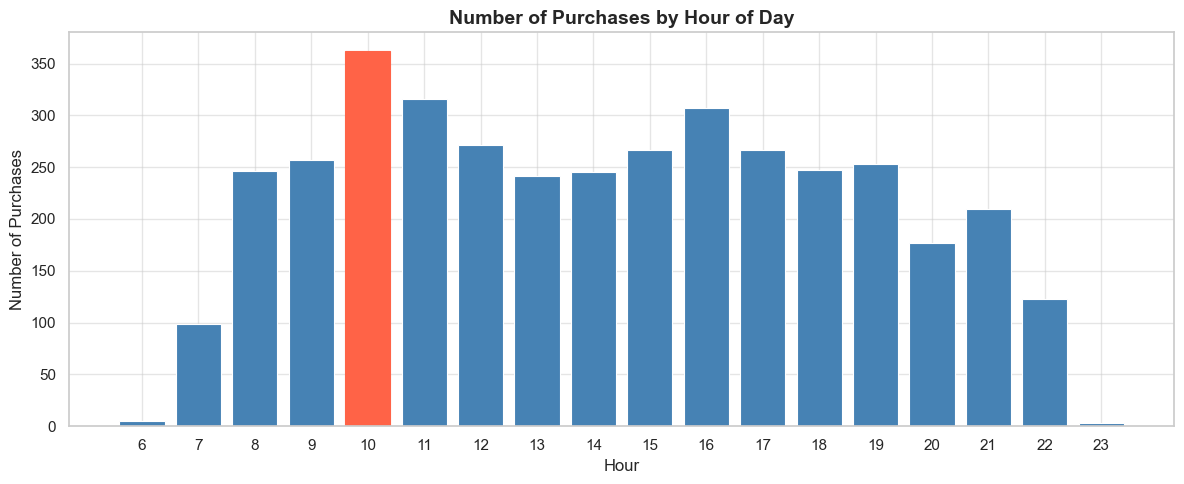

Peak hour is 10:00 with 362 purchases (highlighted in red).


In [17]:
# Plot 2 — Bar chart: number of purchases by hour of day
hour_counts = df['hour'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(hour_counts.index, hour_counts.values, color='steelblue', edgecolor='white', linewidth=0.8)
# Highlight peak hour
peak_hour = hour_counts.idxmax()
bars[hour_counts.index.get_loc(peak_hour)].set_color('tomato')
ax.set_title('Number of Purchases by Hour of Day', fontsize=14, fontweight='bold')
ax.set_xlabel('Hour')
ax.set_ylabel('Number of Purchases')
ax.set_xticks(range(6, 24))
plt.tight_layout()
plt.show()
print(f'Peak hour is {peak_hour}:00 with {hour_counts[peak_hour]} purchases (highlighted in red).')

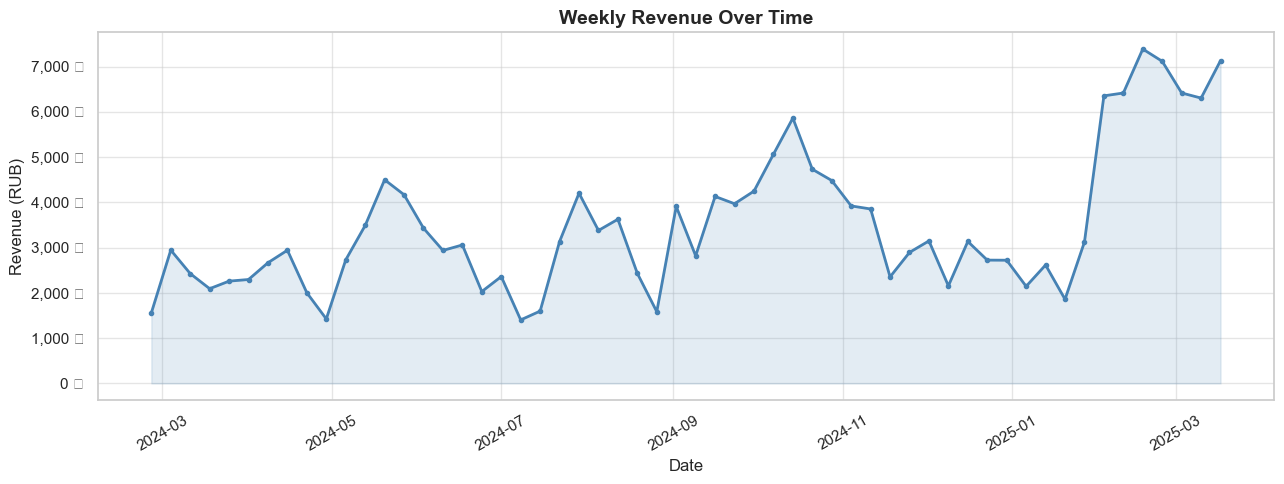

Revenue fluctuates week to week with no clear long-term trend.


In [18]:
# Plot 3 — Line chart: weekly revenue over time
weekly = (df.groupby(df['date'].dt.to_period('W'))['money'].sum().reset_index())
weekly['date'] = weekly['date'].dt.to_timestamp()

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(weekly['date'], weekly['money'], color='steelblue', linewidth=2, marker='o', markersize=3)
ax.fill_between(weekly['date'], weekly['money'], alpha=0.15, color='steelblue')
ax.set_title('Weekly Revenue Over Time', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Revenue (RUB)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f} ₽'))
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()
print('Revenue fluctuates week to week with no clear long-term trend.')

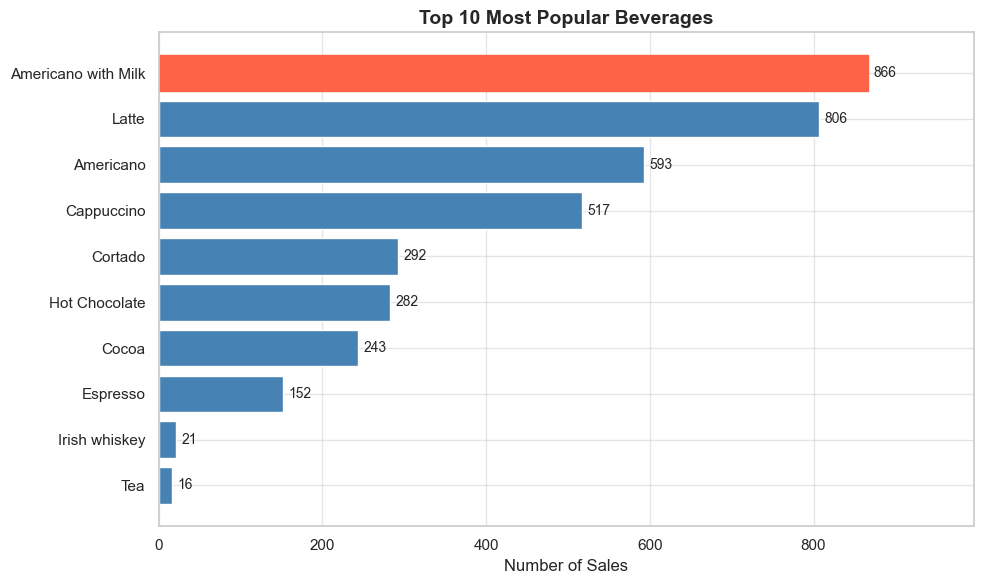

The most popular drink is "Americano with Milk" with 866 sales.


In [19]:
# Plot 4 — Horizontal bar chart: top 10 most popular beverages
top10 = df['coffee_name'].value_counts().head(10).sort_values()

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(top10.index, top10.values, color='steelblue', edgecolor='white')
bars[-1].set_color('tomato')  # highlight the most popular
ax.bar_label(bars, padding=4, fontsize=10)
ax.set_title('Top 10 Most Popular Beverages', fontsize=14, fontweight='bold')
ax.set_xlabel('Number of Sales')
ax.set_xlim(0, top10.values.max() * 1.15)
plt.tight_layout()
plt.show()
print(f'The most popular drink is "{top10.index[-1]}" with {top10.values[-1]} sales.')

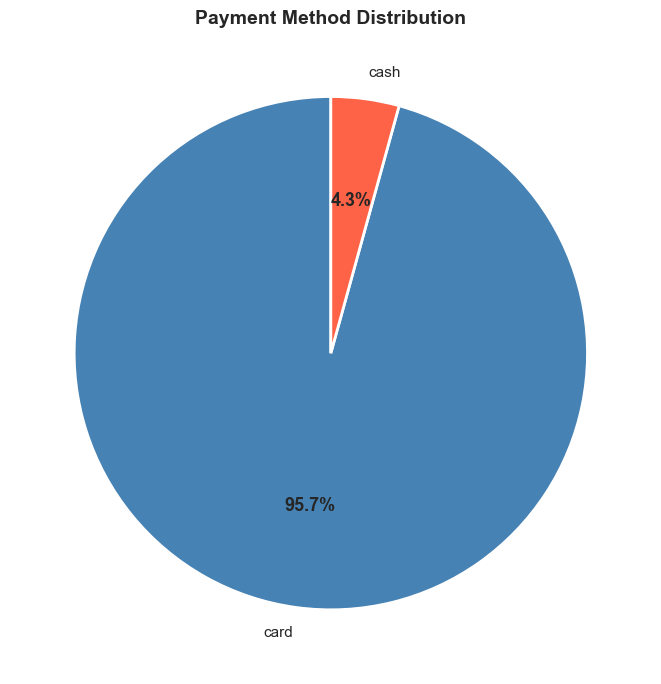

Card payments dominate: 95.7% of all transactions.


In [20]:
# Plot 5 — Pie chart: cash vs card payment share
pay_counts = df['cash_type'].value_counts()

fig, ax = plt.subplots(figsize=(7, 7))
wedges, texts, autotexts = ax.pie(
    pay_counts.values,
    labels=pay_counts.index,
    autopct='%1.1f%%',
    colors=['steelblue', 'tomato'],
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
for text in autotexts:
    text.set_fontsize(13)
    text.set_fontweight('bold')
ax.set_title('Payment Method Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
pct = pay_counts['card'] / pay_counts.sum() * 100
print(f'Card payments dominate: {pct:.1f}% of all transactions.')

## 6. More Detailed Overview

We now look at relationships between variables: how revenue changes by day of week, how card vs cash customers differ across hours, and which beverages generate the most revenue vs the most transactions.

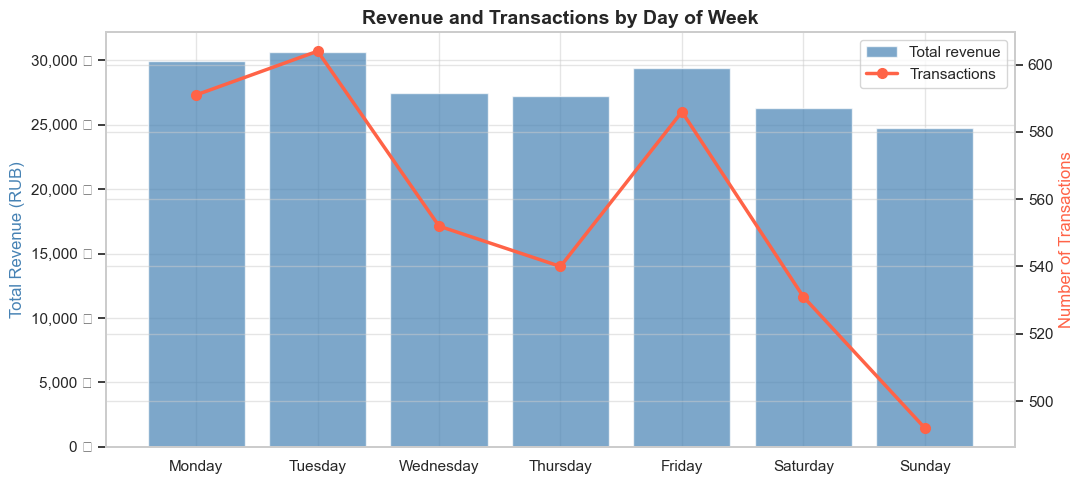

Monday and Tuesday lead in both revenue and transaction count; Sunday is the quietest day.


In [21]:
# Plot 6 — Revenue and transaction count by day of week (two y-axes)
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_stats = df.groupby('day_name')['money'].agg(total='sum', count='count').reindex(day_order)

fig, ax1 = plt.subplots(figsize=(11, 5))
ax2 = ax1.twinx()

bars = ax1.bar(day_stats.index, day_stats['total'], color='steelblue', alpha=0.7, label='Total revenue')
ax2.plot(day_stats.index, day_stats['count'], color='tomato', linewidth=2.5, marker='o', markersize=7, label='Transactions')

ax1.set_ylabel('Total Revenue (RUB)', color='steelblue')
ax2.set_ylabel('Number of Transactions', color='tomato')
ax1.set_title('Revenue and Transactions by Day of Week', fontsize=14, fontweight='bold')
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f} ₽'))

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')
plt.tight_layout()
plt.show()
print('Monday and Tuesday lead in both revenue and transaction count; Sunday is the quietest day.')

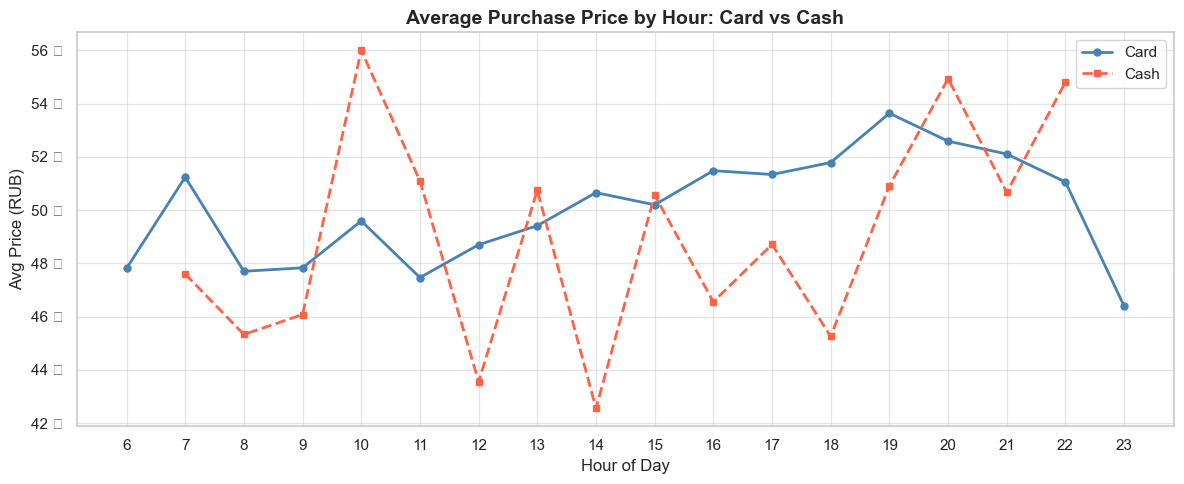

Card prices rise steadily through the day. Cash spending is more volatile due to fewer transactions.


In [22]:
# Plot 7 — Avg price by hour: card vs cash on the same figure
hour_pay = df.groupby(['hour', 'cash_type'])['money'].mean().unstack()

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(hour_pay.index, hour_pay['card'], color='steelblue', linewidth=2, marker='o', markersize=5, label='Card')
ax.plot(hour_pay.index, hour_pay['cash'], color='tomato', linewidth=2, marker='s', markersize=5, label='Cash', linestyle='--')
ax.set_title('Average Purchase Price by Hour: Card vs Cash', fontsize=14, fontweight='bold')
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Avg Price (RUB)')
ax.set_xticks(range(6, 24))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0f} ₽'))
ax.legend()
plt.tight_layout()
plt.show()
print('Card prices rise steadily through the day. Cash spending is more volatile due to fewer transactions.')

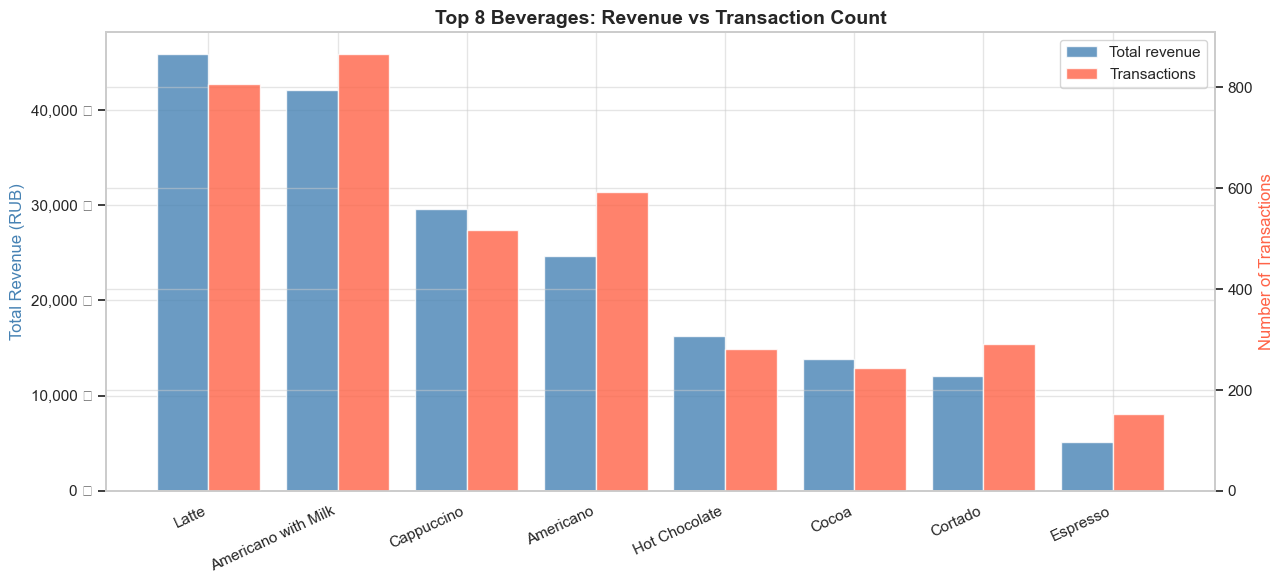

Latte leads in revenue despite being 2nd in sales — its high price makes the difference.
Americano with Milk sells the most but earns less per cup.


In [23]:
# Plot 8 — Top 8 beverages: revenue vs transaction count (grouped bar)
top8_names = df.groupby('coffee_name')['money'].sum().nlargest(8).index
bev = df[df['coffee_name'].isin(top8_names)].groupby('coffee_name')['money'].agg(revenue='sum', count='count').sort_values('revenue', ascending=False)

x = np.arange(len(bev))
width = 0.4

fig, ax1 = plt.subplots(figsize=(13, 6))
ax2 = ax1.twinx()

ax1.bar(x - width/2, bev['revenue'], width, color='steelblue', alpha=0.8, label='Total revenue')
ax2.bar(x + width/2, bev['count'],   width, color='tomato', alpha=0.8, label='Transactions')

ax1.set_xticks(x)
ax1.set_xticklabels(bev.index, rotation=25, ha='right')
ax1.set_ylabel('Total Revenue (RUB)', color='steelblue')
ax2.set_ylabel('Number of Transactions', color='tomato')
ax1.set_title('Top 8 Beverages: Revenue vs Transaction Count', fontsize=14, fontweight='bold')
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f} ₽'))

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')
plt.tight_layout()
plt.show()
print('Latte leads in revenue despite being 2nd in sales — its high price makes the difference.')
print('Americano with Milk sells the most but earns less per cup.')

## 7. Data Transformation

We derive four new columns from existing data to enrich the dataset for analysis:

- **`time_of_day`** — groups purchases into Morning / Afternoon / Evening / Night
- **`is_weekend`** — boolean flag for Saturday and Sunday
- **`price_category`** — classifies each purchase as Budget / Mid-range / Premium
- **`revenue_rank`** — percentile rank of that day's total revenue among all days (0 = lowest, 1 = highest)

In [24]:
# Column 1: time_of_day
def time_of_day(h):
    if 6  <= h < 12:
        return 'Morning'
    elif 12 <= h < 17:
        return 'Afternoon'
    elif 17 <= h < 21:
        return 'Evening'
    else:
        return 'Night'

df['time_of_day'] = df['hour'].apply(time_of_day)

# Column 2: is_weekend
df['is_weekend'] = df['day_of_week'].isin([5, 6])

# Column 3: price_category
df['price_category'] = pd.cut(
    df['money'],
    bins = [0, 35, 50, 65],
    labels = ['Budget', 'Mid-range', 'Expensive']
)

# Column 4: revenue_rank — percentile rank of daily revenue
daily_rev = df.groupby('date')['money'].sum()
df['revenue_rank'] = df['date'].map(daily_rev).rank(pct=True).round(2)

print('New columns added:')
print(df[['datetime', 'money', 'time_of_day', 'is_weekend', 'price_category', 'revenue_rank']].head(10))

New columns added:
                 datetime  money time_of_day  is_weekend price_category  \
0 2024-03-01 10:15:50.520  61.92     Morning       False      Expensive   
1 2024-03-01 12:19:22.539  61.92   Afternoon       False      Expensive   
2 2024-03-01 12:20:18.089  61.92   Afternoon       False      Expensive   
3 2024-03-01 13:46:33.006  46.24   Afternoon       False      Mid-range   
4 2024-03-01 13:48:14.626  61.92   Afternoon       False      Expensive   
5 2024-03-01 15:39:47.726  54.08   Afternoon       False      Expensive   
6 2024-03-01 16:19:02.756  61.92   Afternoon       False      Expensive   
7 2024-03-01 18:39:03.580  54.08     Evening       False      Expensive   
8 2024-03-01 19:22:01.762  61.92     Evening       False      Expensive   
9 2024-03-01 19:23:15.887  54.08     Evening       False      Expensive   

   revenue_rank  
0          0.53  
1          0.53  
2          0.53  
3          0.53  
4          0.53  
5          0.53  
6          0.53  
7          

In [25]:
# Summary of new columns
print('--- time_of_day ---')
print(df['time_of_day'].value_counts())

print('\n--- is_weekend ---')
wd = df['is_weekend'].value_counts().rename({False: 'Weekday', True: 'Weekend'})
print(wd)

print('\n--- price_category ---')
print(df['price_category'].value_counts())

print('\n--- revenue_rank (sample of extreme days) ---')
daily = df[['date', 'daily_revenue', 'revenue_rank']].drop_duplicates().sort_values('revenue_rank')
print('Lowest revenue days:')
print(daily.head(3).to_string(index=False))
print('Highest revenue days:')
print(daily.tail(3).to_string(index=False))

--- time_of_day ---
time_of_day
Afternoon    1331
Morning      1285
Evening       944
Night         336
Name: count, dtype: int64

--- is_weekend ---
is_weekend
Weekday    2873
Weekend    1023
Name: count, dtype: int64

--- price_category ---
price_category
Expensive    2048
Mid-range    1719
Budget        129
Name: count, dtype: int64

--- revenue_rank (sample of extreme days) ---
Lowest revenue days:
      date  daily_revenue  revenue_rank
2024-07-16          97.18           0.0
2024-07-15          52.51           0.0
2024-04-27          60.35           0.0
Highest revenue days:
      date  daily_revenue  revenue_rank
2025-03-03        1428.44          0.98
2025-02-26        1560.36          0.99
2025-02-21        1566.62          1.00


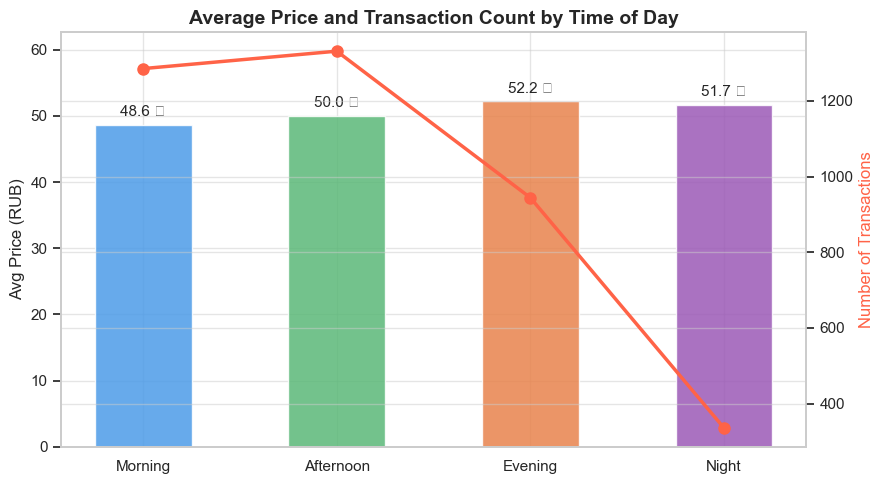

Evening and Night purchases have a slightly higher average price than Morning.


In [26]:
# Plot 9 — Avg price and transaction count by time of day
tod_order = ['Morning', 'Afternoon', 'Evening', 'Night']
tod_stats = df.groupby('time_of_day', observed=True)['money'].agg(avg_price='mean', count='count').reindex(tod_order)

fig, ax1 = plt.subplots(figsize=(9, 5))
ax2 = ax1.twinx()

colors = ['#4C9BE8', '#5BB878', '#E8834C', '#9B59B6']
bars = ax1.bar(tod_stats.index, tod_stats['avg_price'], color=colors, alpha=0.85, width=0.5)
ax1.bar_label(bars, fmt='%.1f ₽', padding=4, fontsize=11)
ax2.plot(tod_stats.index, tod_stats['count'], color='tomato', linewidth=2.5, marker='o', markersize=8, label='Transactions')

ax1.set_ylabel('Avg Price (RUB)', fontsize=12)
ax2.set_ylabel('Number of Transactions', color='tomato', fontsize=12)
ax1.set_title('Average Price and Transaction Count by Time of Day', fontsize=14, fontweight='bold')
ax1.set_ylim(0, tod_stats['avg_price'].max() * 1.2)
plt.tight_layout()
plt.show()
print('Evening and Night purchases have a slightly higher average price than Morning.')

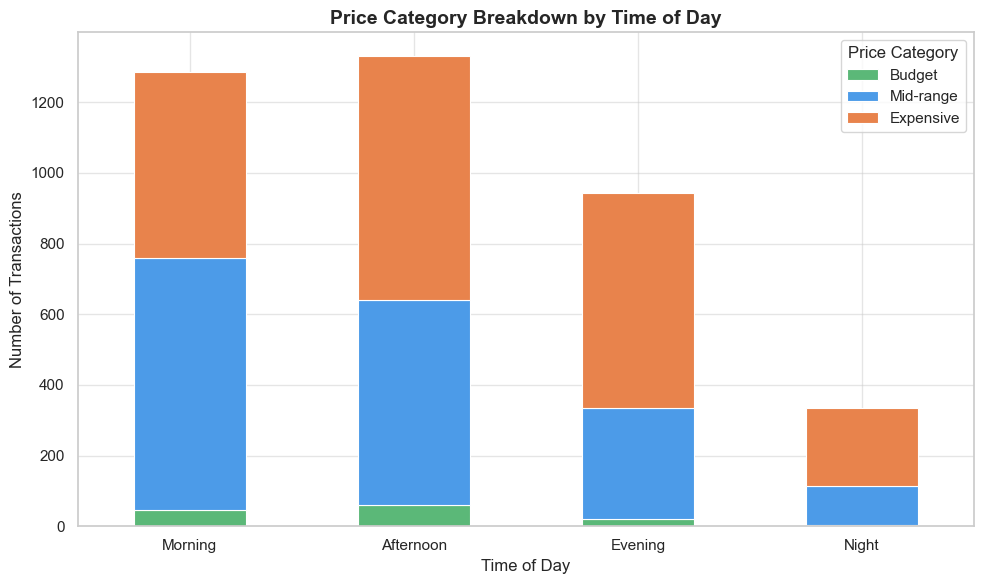

Premium purchases are present in all time slots, but Morning has the highest absolute count.


In [27]:
# Plot 10 — Price category breakdown by time of day (stacked bar)
cat_tod = df.groupby(['time_of_day', 'price_category'], observed=True).size().unstack()
cat_tod = cat_tod.reindex(tod_order)

cat_tod.plot(
    kind='bar',
    stacked=True,
    color=['#5BB878', '#4C9BE8', '#E8834C'],
    figsize=(10, 6),
    edgecolor='white',
    linewidth=0.8
)
plt.title('Price Category Breakdown by Time of Day', fontsize=14, fontweight='bold')
plt.xlabel('Time of Day')
plt.ylabel('Number of Transactions')
plt.xticks(rotation=0)
plt.legend(title='Price Category')
plt.tight_layout()
plt.show()
print('Premium purchases are present in all time slots, but Morning has the highest absolute count.')

## 8. Hypothesis Checking

We test two hypotheses using independent samples t-tests (significance level α = 0.05).

### Hypothesis 1
**"Card payments have a higher average purchase price than cash payments."**

The idea: card users might be less price-sensitive and tend to order more expensive drinks.

In [28]:
from scipy import stats

card_prices = df[df['cash_type'] == 'card']['money']
cash_prices = df[df['cash_type'] == 'cash']['money']

print('=== Hypothesis 1: Card vs Cash average price ===')
print(f'Card — mean: {card_prices.mean():.2f} ₽, median: {card_prices.median():.2f} ₽, n={len(card_prices)}')
print(f'Cash — mean: {cash_prices.mean():.2f} ₽, median: {cash_prices.median():.2f} ₽, n={len(cash_prices)}')

t_stat, p_val = stats.ttest_ind(card_prices, cash_prices)
print(f'\nt-statistic: {t_stat:.4f}')
print(f'p-value:     {p_val:.4f}')
print(f'\nConclusion: p = {p_val:.4f} > 0.05 — the difference is NOT statistically significant.')
print('Hypothesis 1 is REJECTED.')

=== Hypothesis 1: Card vs Cash average price ===
Card — mean: 50.25 ₽, median: 52.51 ₽, n=3729
Cash — mean: 49.41 ₽, median: 48.00 ₽, n=167

t-statistic: 1.3159
p-value:     0.1883

Conclusion: p = 0.1883 > 0.05 — the difference is NOT statistically significant.
Hypothesis 1 is REJECTED.


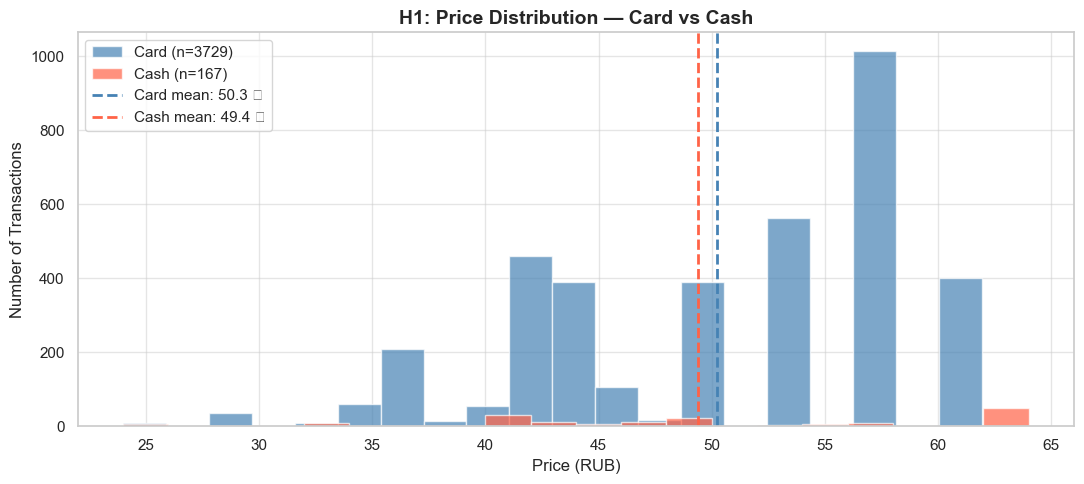

Means are close (50.25 vs 49.41 ₽). With p=0.188 the difference is not significant.


In [29]:
# Plot 11 — H1: Histogram of prices: card vs cash
fig, ax = plt.subplots(figsize=(11, 5))

ax.hist(card_prices, bins=20, alpha=0.7, color='steelblue', label=f'Card (n={len(card_prices)})', edgecolor='white')
ax.hist(cash_prices, bins=20, alpha=0.7, color='tomato', label=f'Cash (n={len(cash_prices)})',  edgecolor='white')

ax.axvline(card_prices.mean(), color='steelblue', linestyle='--', linewidth=2, label=f'Card mean: {card_prices.mean():.1f} ₽')
ax.axvline(cash_prices.mean(), color='tomato',    linestyle='--', linewidth=2, label=f'Cash mean: {cash_prices.mean():.1f} ₽')

ax.set_title('H1: Price Distribution — Card vs Cash', fontsize=14, fontweight='bold')
ax.set_xlabel('Price (RUB)')
ax.set_ylabel('Number of Transactions')
ax.legend()
plt.tight_layout()
plt.show()
print(f'Means are close (50.25 vs 49.41 ₽). With p={p_val:.3f} the difference is not significant.')

### Hypothesis 2
**"Daily revenue is higher on weekends than on weekdays."**

The idea: people have more free time on weekends and might visit the coffee machine more often.

In [30]:
daily = df.groupby('date').agg(
    revenue = ('money', 'sum'),
    is_weekend = ('is_weekend', 'first')
)

weekend_rev = daily[daily['is_weekend']]['revenue']
weekday_rev = daily[~daily['is_weekend']]['revenue']

print('=== Hypothesis 2: Weekend vs Weekday daily revenue ===')
print(f'Weekend — mean: {weekend_rev.mean():.2f} ₽, median: {weekend_rev.median():.2f} ₽, n={len(weekend_rev)} days')
print(f'Weekday — mean: {weekday_rev.mean():.2f} ₽, median: {weekday_rev.median():.2f} ₽, n={len(weekday_rev)} days')

t_stat2, p_val2 = stats.ttest_ind(weekend_rev, weekday_rev)
print(f'\nt-statistic: {t_stat2:.4f}')
print(f'p-value: {p_val2:.4f}')
print(f'\nConclusion: p = {p_val2:.4f} > 0.05 — the difference is NOT statistically significant.')
print('Hypothesis 2 is REJECTED.')
print('Weekdays actually earn MORE on average, but the gap is not statistically proven.')

=== Hypothesis 2: Weekend vs Weekday daily revenue ===
Weekend — mean: 467.81 ₽, median: 446.70 ₽, n=109 days
Weekday — mean: 531.80 ₽, median: 456.18 ₽, n=272 days

t-statistic: -1.9222
p-value: 0.0553

Conclusion: p = 0.0553 > 0.05 — the difference is NOT statistically significant.
Hypothesis 2 is REJECTED.
Weekdays actually earn MORE on average, but the gap is not statistically proven.


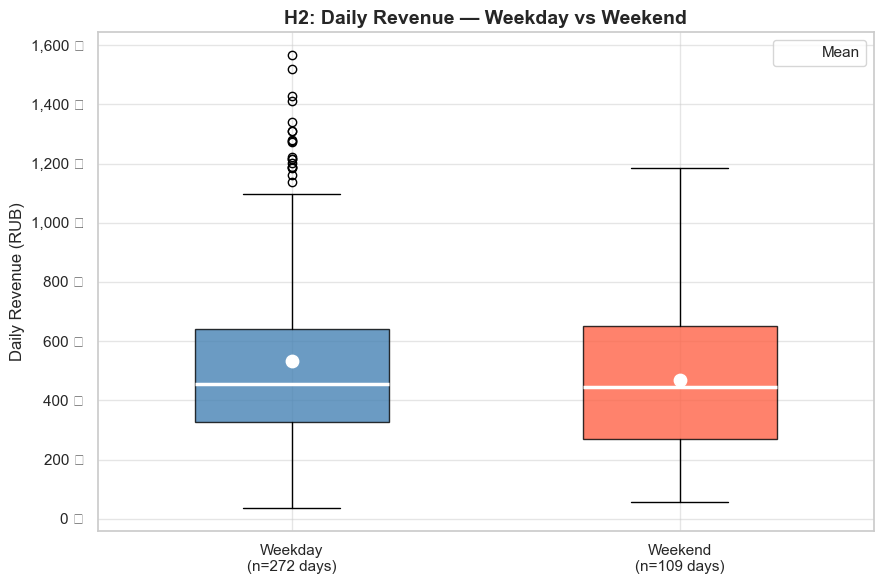

Weekdays: mean 532 ₽ vs Weekend: mean 468 ₽.
Weekdays earn ~64 ₽ more on average, but p=0.055 — not significant.


In [31]:
# Plot 12 — H2: Box plot of daily revenue: weekday vs weekend
fig, ax = plt.subplots(figsize=(9, 6))

data_to_plot = [weekday_rev.values, weekend_rev.values]
bp = ax.boxplot(data_to_plot, patch_artist=True, widths=0.5, medianprops=dict(color='white', linewidth=2.5))

colors_box = ['steelblue', 'tomato']
for patch, color in zip(bp['boxes'], colors_box):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)

ax.set_xticks([1, 2])
ax.set_xticklabels([f'Weekday\n(n={len(weekday_rev)} days)', f'Weekend\n(n={len(weekend_rev)} days)'])
ax.set_ylabel('Daily Revenue (RUB)')
ax.set_title('H2: Daily Revenue — Weekday vs Weekend', fontsize=14, fontweight='bold')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f} ₽'))

# Add mean markers
ax.scatter([1, 2], [weekday_rev.mean(), weekend_rev.mean()], color='white', s=80, zorder=5, label='Mean')
ax.legend()
plt.tight_layout()
plt.show()
print(f'Weekdays: mean {weekday_rev.mean():.0f} ₽ vs Weekend: mean {weekend_rev.mean():.0f} ₽.')
print(f'Weekdays earn ~{weekday_rev.mean()-weekend_rev.mean():.0f} ₽ more on average, but p={p_val2:.3f} — not significant.')

## 9. Discussion

In this section we summarise the key findings from each step of the analysis.

### Dataset
The dataset contains **3,896 transactions** from a coffee vending machine covering the period March 2024 – March 2025. It was composed of two files with slightly different structures (one had card numbers, the other did not) and required merging, type conversion, and cleanup before analysis.

### Data Cleanup
Three issues were found and fixed:
- **2 duplicate rows** — removed
- **NaN in the `card` column** — expected for cash payments; card transactions from `index_2.csv` had no card number and were filled with `'unknown'`
- **Inconsistent capitalisation** — `'Americano with milk'` and `'Americano with Milk'` were the same drink; merged into one name, reducing unique beverages from 34 to 33

### Descriptive Statistics
The average purchase price is **50.21 ₽** with a median of **52.51 ₽**, indicating a slight left skew — a minority of cheap drinks (Tea at 24 ₽, Espresso at 33 ₽) pull the mean down. Purchases happen between 6:00 and 23:00, peaking around 10:00. Average daily revenue is **688 ₽**, ranging from 37 ₽ to 1,567 ₽.

### Plots & Detailed Overview
- The price distribution shows two clusters: around **45 ₽** (Americano, Cortado, Espresso) and **57 ₽** (Latte, Cappuccino, Hot Chocolate)
- The most popular drink by sales is **Americano with Milk** (866 orders), but **Latte** generates the most total revenue (45,854 ₽) due to its higher price
- **Card payments dominate** — over 95% of all transactions; cash is rare
- Monday and Tuesday are the busiest days; Sunday is the quietest
- Average price rises slightly through the day: morning purchases average **48.6 ₽**, evening **52.2 ₽**

### Data Transformation
Four new columns were added. The `time_of_day` breakdown shows that most purchases happen in the **Morning and Afternoon** (together ~67% of all transactions). The `price_category` column reveals that **Premium** drinks (above 50 ₽) account for the majority of orders — customers generally prefer mid-to-high priced beverages.

### Hypothesis Testing
**H1** (card users spend more than cash users) was **rejected** (p = 0.188). The means differ by less than 1 ₽, which is not statistically significant. Payment method does not predict spending level.

**H2** (weekend revenue is higher than weekday revenue) was also **rejected** (p = 0.055). Interestingly, the result is the opposite of what we expected: weekdays average **532 ₽/day** vs weekends **468 ₽/day**. The p-value is very close to 0.05, suggesting a trend but not enough evidence to confirm it statistically. This may reflect the machine's location — likely in an office or campus building with lower foot traffic on weekends.